# Two Moons

The Two Moons dataset is a simple synthetic dataset used in machine learning for binary classification tasks. It consists of two interleaving crescent-shaped clusters (or "moons") in two-dimensional space, making it a standard benchmark for testing nonlinear classification algorithms.

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Shape of X: (1000, 2)
Shape of y: (1000,)


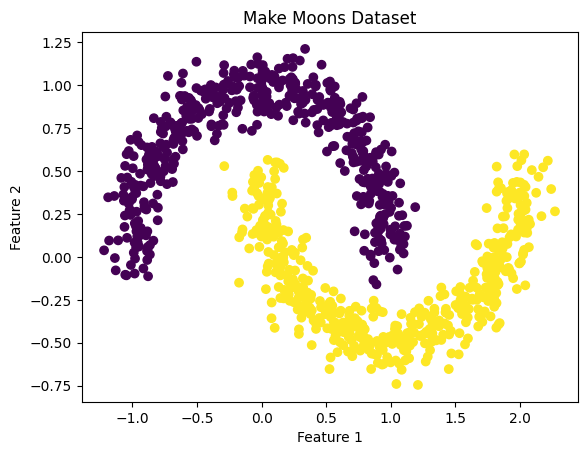

In [2]:


X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# X contains the features (coordinates), and y contains the labels (0 or 1)
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Example of how to plot the data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [3]:
train_X, train_y = X[:800], y[:800]
test_X, test_y = X[800:900], y[800:900]
validation_X, validation_y = X[900:1000], y[900:1000]

In [4]:
hidden_layer_size = 10
input_size = train_X.shape[1]  # Number of features (2 for the moons dataset)
output_size = 1  # Binary classification

## Inititalize Weights and Biases

In [5]:
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_layer_size) * np.sqrt(1 / input_size)
B1 = np.zeros((1, hidden_layer_size))
W2 = np.random.randn(hidden_layer_size, output_size) * np.sqrt(1 / hidden_layer_size)
B2 = np.zeros((1, output_size))

## Functions

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

## Cost Function

The binary cross-entropy loss is:

$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where $m$ is the number of samples.


In [7]:
def cost_function(y_true, y_pred):
    m = len(y_true)
    cost = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return cost

When $\hat{y} = \sigma(z)$, the chain rule gives:

$$\frac{\partial J}{\partial z} = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y}) = \hat{y} - y$$

In [8]:
def cost_derivative(y_true, y_pred):
    return y_pred - y_true.reshape(-1, 1)

## Backpropagation

In [9]:
m = X.shape[0]
learning_rate = 0.1
epochs = 20000
costs = []
for epoch in range(epochs):
    # Forward Propagation
    Z1 = train_X @ W1 + B1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + B2
    A2 = sigmoid(Z2)
    # Compute Cost
    cost = cost_function(train_y.reshape(-1, 1), A2)
    costs.append(cost)
    # Backward Propagation
    dZ2 = cost_derivative(train_y, A2) * sigmoid_derivative(Z2) / m
    dW2 = A1.T @ dZ2
    dB2 = np.mean(dZ2, axis=0, keepdims=True)
    dZ1 = dZ2 @ W2.T * sigmoid_derivative(Z1)
    dW1 = train_X.T @ dZ1
    dB1 = np.mean(dZ1, axis=0, keepdims=True)
    # Update Weights and Biases
    W2 -= learning_rate * dW2
    B2 -= learning_rate * dB2
    W1 -= learning_rate * dW1
    B1 -= learning_rate * dB1

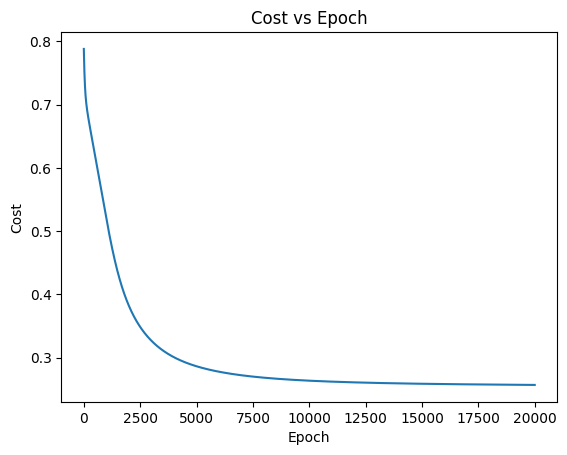

In [10]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.title("Cost vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

## Test the model

In [11]:
def feed_forward(X):
    Z1 = X @ W1 + B1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + B2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

In [12]:

prediction = feed_forward(test_X)
compute_accuracy = np.mean(prediction.flatten() == test_y)
print("Test Accuracy:", compute_accuracy)

Test Accuracy: 0.85
